## import python libraries
## References

- Paleomagnetic source: LULEÅ WORKING GROUP MEAN (2009).
- Geochronology / age-constraint note (compilation): 1415-1445, range of ages


In [52]:
import sys
sys.path.append('../data/')
from pole_tools import *

Laurentia_poles = get_Laurentia_poles() # get all poles
Laurentia_stricto_poles = get_Laurentia_stricto_poles() # get only Laurentia poles

%config InlineBackend.figure_format='retina'
%matplotlib inline

## import data from Harlan et al 1994 and Harland et al., 1998

These two publications include pmag data from the Electra Lake gabbro and Laramie anorthosite and the Sherman granite

In [ ]:
Rockys_sites_geo, Rockys_sites_tc = load_magic_sites('../data/1430_Rocky/sites.txt')
Rockys_geo = Rockys_sites_geo.rename(columns={'description': 'rock type', 'dir_dec': 'dec', 'dir_inc': 'inc', 'dir_k': 'k', 'dir_alpha95': 'alpha95'})
Rockys_tc = Rockys_sites_tc.rename(columns={'dir_dec': 'dec_tc', 'dir_inc': 'inc_tc'})
Rockys_df = Rockys_geo[['site', 'rock type', 'lat', 'lon', 'n', 'N', 'dec', 'inc', 'strike', 'dip', 'k', 'alpha95']].merge(Rockys_tc[['site', 'dec_tc', 'inc_tc', 'vgp_lat', 'vgp_lon']], on='site', how='left').reset_index(drop=True)
Rockys_df = Rockys_df[Rockys_df['alpha95']<20]
Rockys_df = Rockys_df[Rockys_df['n']>=3]
Rockys_df = Rockys_df.reset_index(drop=True)
Rockys_df['dip_dir'] = Rockys_df['strike']+90
Rockys_df

,rock type,lat,lon,n,N,dec,inc,strike,dip,dec_tc,inc_tc,k,alpha95,Plat,Plon,unit,dip_dir
site,,,,,,,,,,,,,,,,,
LI,An,41.8000,254.6700,5,10,48.3,-55.8,110.0,50.0,35.6,-8.8,215.0,5.2,-0.3,217.6,Laramie anorthosite,200.0
L2,An,41.7820,254.6750,10,10,40.4,-39.0,0.0,50.0,345.0,-52.2,46.0,7.2,-16.1,215.9,Laramie anorthosite,90.0
L3,Sy,41.7080,254.4830,7,8,47.1,-53.6,240.0,23.0,78.4,-52.4,51.0,7.4,-2.7,217.2,Laramie anorthosite,330.0
Lal,Sy,41.7010,254.4990,7,8,46.1,-40.4,0.0,0.0,46.1,-40.4,93.0,6.3,-12.4,211.9,Laramie anorthosite,90.0
La2,Sy,41.7090,245.5110,11,11,43.4,-48.9,246.0,30.0,80.6,-51.2,174.0,3.5,-8.0,217.6,Laramie anorthosite,336.0
La3,Sy,41.7090,254.5250,7,7,44.1,-49.5,246.0,30.0,81.8,-51.2,229.0,4.0,-7.2,217.4,Laramie anorthosite,336.0
La4,Sy,41.7180,254.5380,6,6,36.8,-47.5,208.0,50.0,71.4,-23.2,116.0,6.3,-11.9,222.1,Laramie anorthosite,298.0
La5,An,51.7800,254.6500,5,7,24.5,-41.5,280.0,35.0,51.2,-73.5,26.0,15.3,-20.6,230.7,Laramie anorthosite,370.0
La6,An,41.7800,254.6520,7,8,42.6,-39.2,280.0,35.0,77.6,-63.1,29.0,11.5,-14.9,214.2,Laramie anorthosite,370.0


In [54]:
Rockys_df.shape

(57, 17)

In [55]:
Rockys_df.n.sum()

453

In [56]:
Rockys_df.N.sum()

514

In [57]:
## igneous layering test


In [ ]:
Rockys_df = ipmag.vgp_calc(Rockys_df, tilt_correction='yes',
                            site_lon='lon',
                            site_lat='lat',
                            dec_tc='dec_tc',
                            inc_tc='inc_tc')
Rockys_df

,rock type,lat,lon,n,N,dec,inc,strike,dip,dec_tc,...,alpha95,Plat,Plon,unit,dip_dir,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev
site,,,,,,,,,,,,,,,,,,,,,
LI,An,41.8000,254.6700,5,10,48.3,-55.8,110.0,50.0,35.6,...,5.2,-0.3,217.6,Laramie anorthosite,200.0,-36.342946,0.255072,37.698958,-0.255072,217.698958
L2,An,41.7820,254.6750,10,10,40.4,-39.0,0.0,50.0,345.0,...,7.2,-16.1,215.9,Laramie anorthosite,90.0,-22.042632,16.039516,35.987017,-16.039516,215.987017
L3,Sy,41.7080,254.4830,7,8,47.1,-53.6,240.0,23.0,78.4,...,7.4,-2.7,217.2,Laramie anorthosite,330.0,-34.144473,2.702487,37.114011,-2.702487,217.114011
Lal,Sy,41.7010,254.4990,7,8,46.1,-40.4,0.0,0.0,46.1,...,6.3,-12.4,211.9,Laramie anorthosite,90.0,-23.051371,12.468030,31.730956,-12.468030,211.730956
La2,Sy,41.7090,245.5110,11,11,43.4,-48.9,246.0,30.0,80.6,...,3.5,-8.0,217.6,Laramie anorthosite,336.0,-29.819643,8.032569,28.496275,-8.032569,208.496275
La3,Sy,41.7090,254.5250,7,7,44.1,-49.5,246.0,30.0,81.8,...,4.0,-7.2,217.4,Laramie anorthosite,336.0,-30.345764,7.267959,37.265078,-7.267959,217.265078
La4,Sy,41.7180,254.5380,6,6,36.8,-47.5,208.0,50.0,71.4,...,6.3,-11.9,222.1,Laramie anorthosite,298.0,-28.619277,11.883097,42.034469,-11.883097,222.034469
La5,An,51.7800,254.6500,5,7,24.5,-41.5,280.0,35.0,51.2,...,15.3,-20.6,230.7,Laramie anorthosite,370.0,-23.862808,11.362904,51.892845,-11.362904,231.892845
La6,An,41.7800,254.6520,7,8,42.6,-39.2,280.0,35.0,77.6,...,11.5,-14.9,214.2,Laramie anorthosite,370.0,-22.185146,14.873876,34.223788,-14.873876,214.223788


## igneous texture fold test

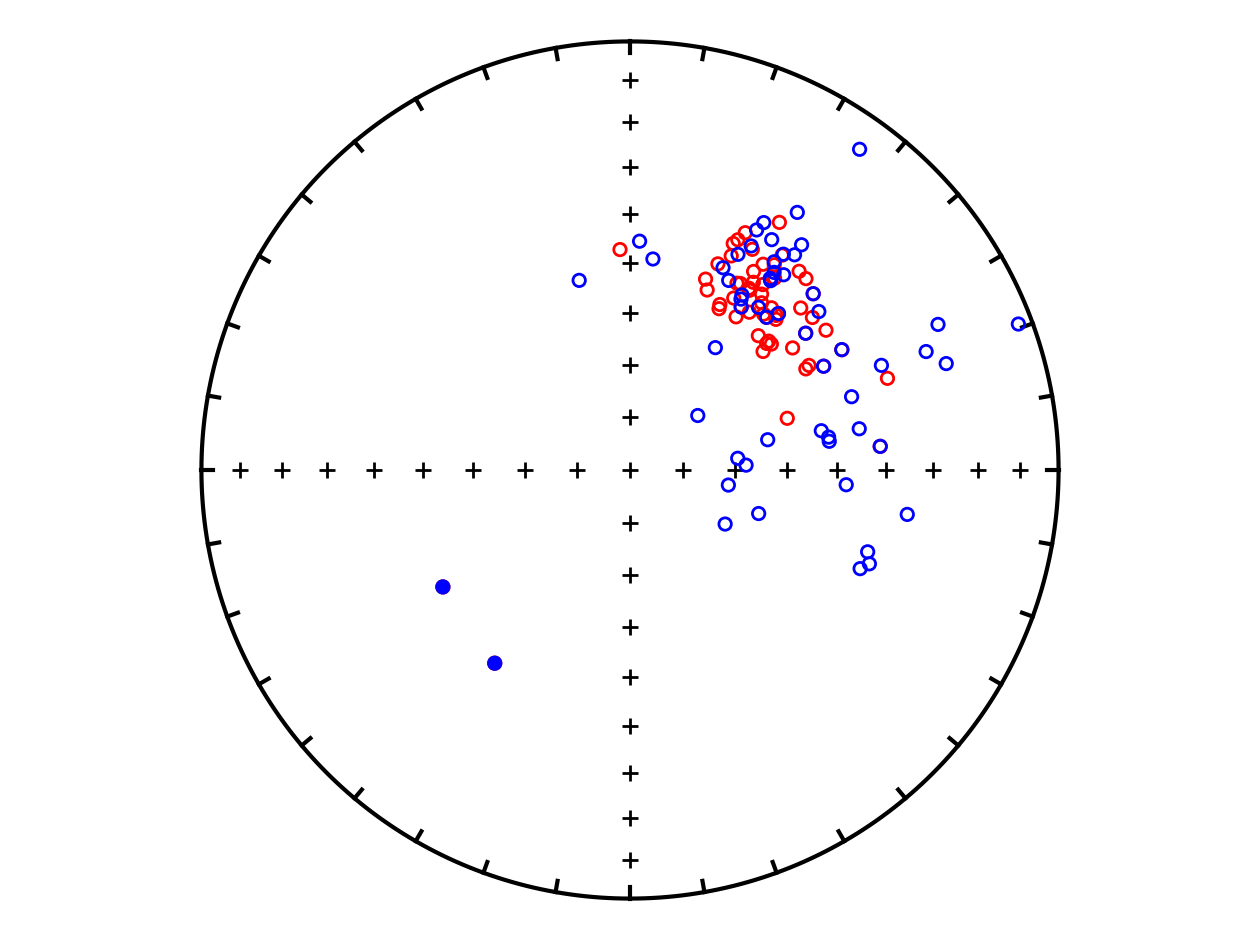

In [59]:
# plot up directions
# tilt results in a worse dispersion of the data
ipmag.plot_net()
ipmag.plot_di(Rockys_df['dec'], Rockys_df['inc'], color='r')
ipmag.plot_di(Rockys_df['dec_tc'], Rockys_df['inc_tc'], color='b')

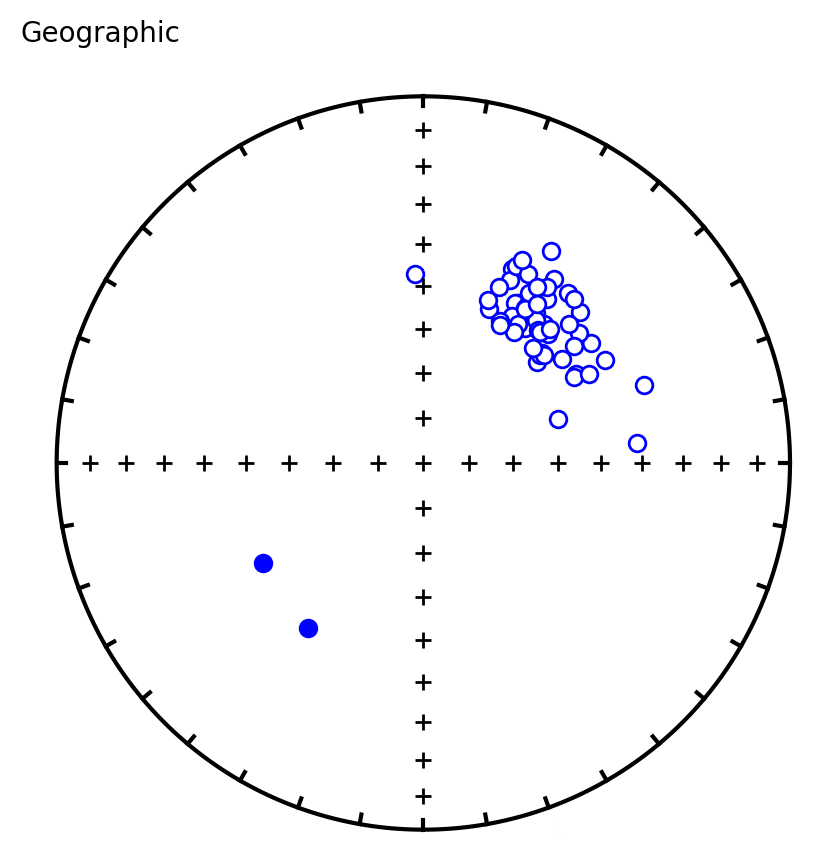

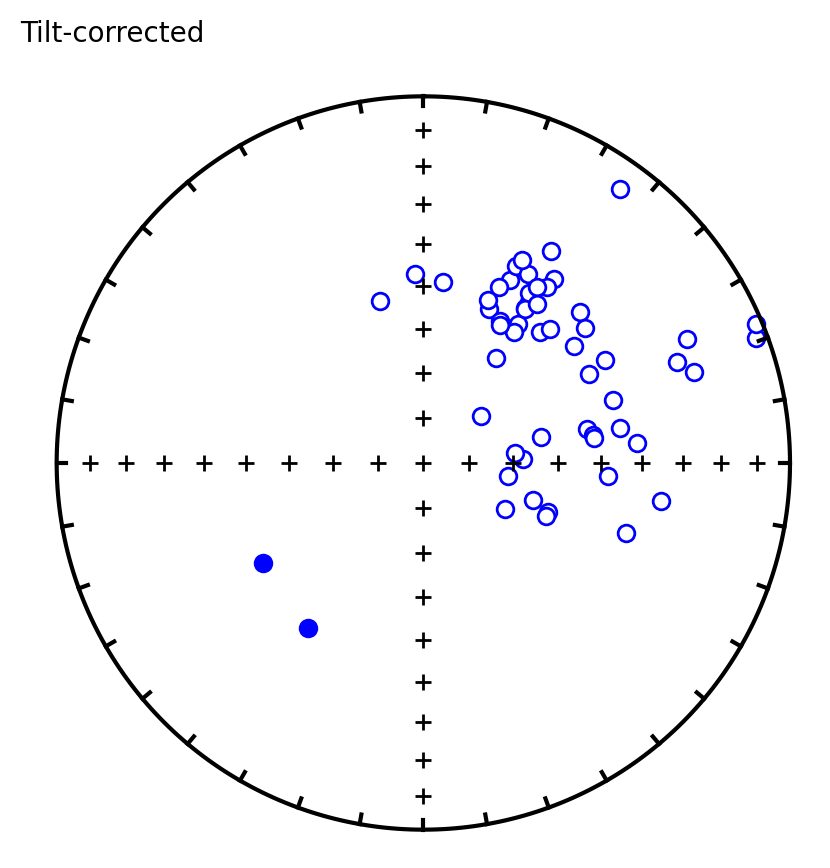

doing  1000  iterations...please be patient.....

tightest grouping of vectors obtained at (95% confidence bounds):
-10 - 7 percent unfolding
range of all bootstrap samples: 
-10  -  13 percent unfolding


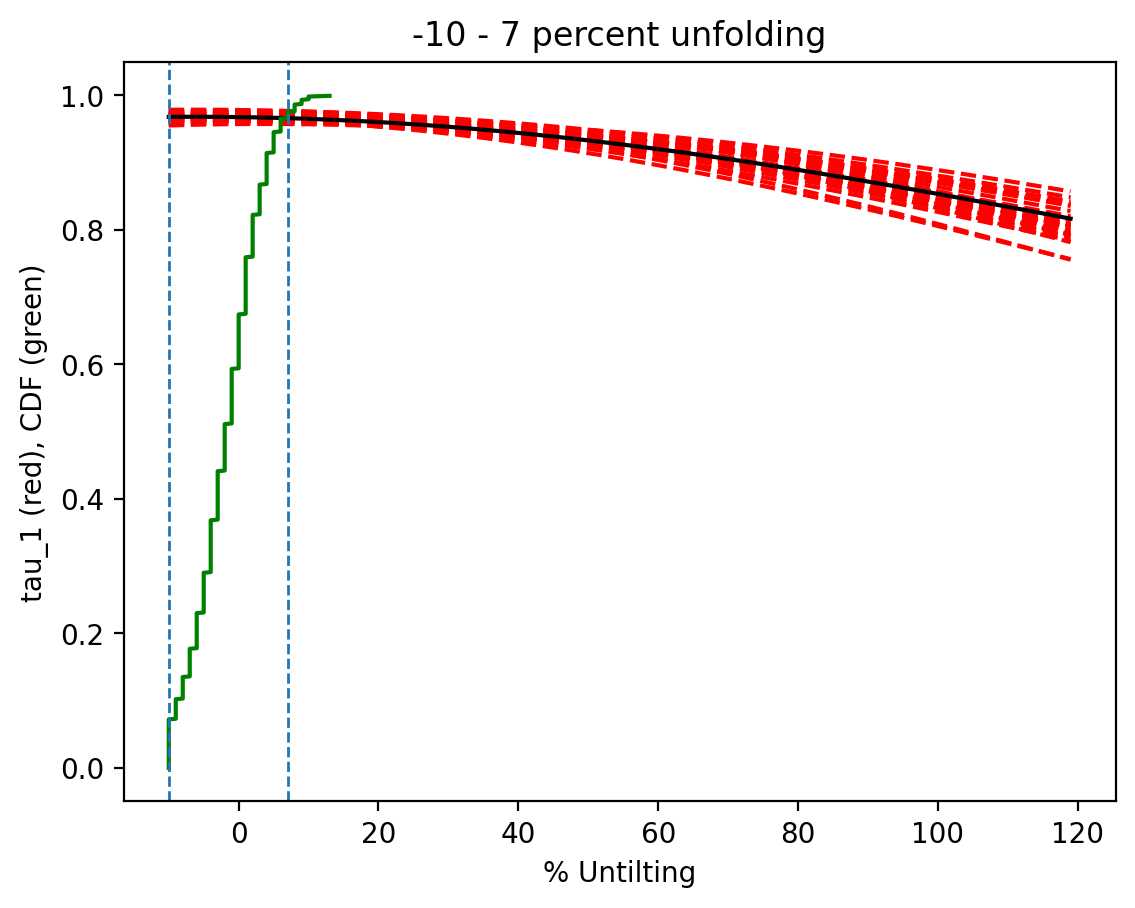

In [60]:
ipmag.bootstrap_fold_test(Rockys_df[['dec', 'inc', 'dip_dir', 'dip']].fillna(0).to_numpy() )

## reversal test

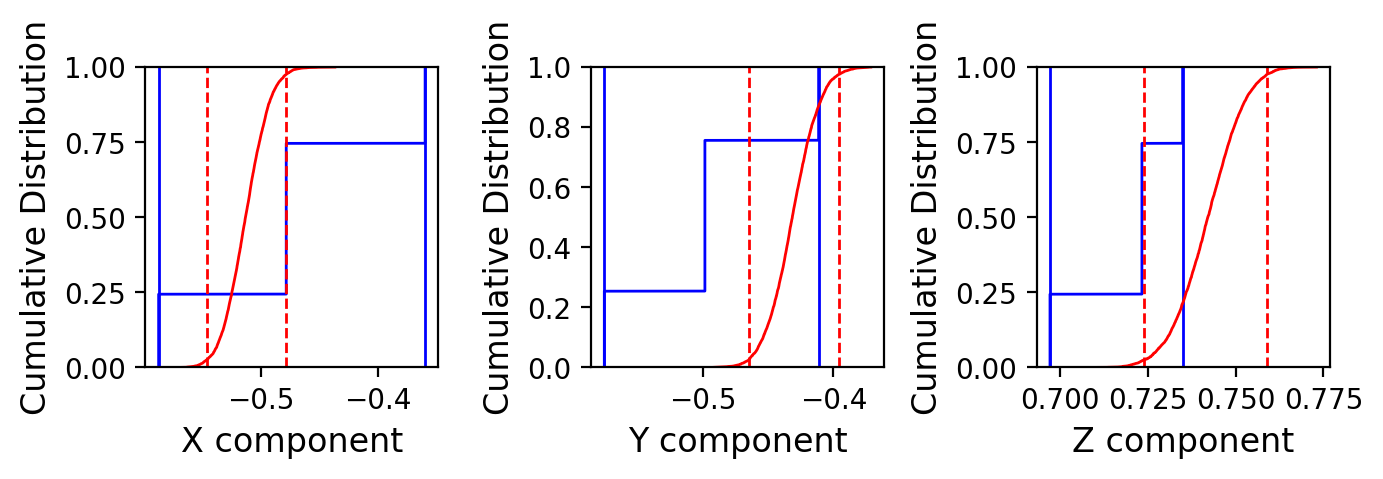

Pass


1

In [61]:
# let's do a reversal test
ipmag.reversal_test_bootstrap(dec=Rockys_df['dec'], inc=Rockys_df['inc'])

In [68]:
ipmag.reversal_test_MM1990(dec=Rockys_df['dec'], inc=Rockys_df['inc'])

Results of Watson V test: 

Watson's V:           0.6
Critical value of V:  23.3
"Pass": Since V is less than Vcrit, the null hypothesis
that the two populations are drawn from distributions
that share a common mean direction can not be rejected.

M&M1990 classification:

Angle between data set means: 4.5
Critical angle for M&M1990:   28.7
The McFadden and McElhinny (1990) classification for
this test is: 'INDETERMINATE;


(1, 4.5042196079986505, 28.68983027209052, 'indeterminate')

In [62]:
ipmag.fisher_mean(Rockys_df['dec'], Rockys_df['inc'])

{'dec': 39.73552743643503,
 'inc': -47.970871500013956,
 'n': 57,
 'r': 51.988031516962884,
 'k': 11.173254618326238,
 'alpha95': 5.90029292537864,
 'csd': 24.232329798228573}

In [63]:
ipmag.fisher_mean(Rockys_df['vgp_lon'], Rockys_df['vgp_lat'])

{'dec': 38.76774185289846,
 'inc': 11.286360418781982,
 'n': 57,
 'r': 51.5328154447756,
 'k': 10.24293206756425,
 'alpha95': 6.189852885873681,
 'csd': 25.308876854216898}

In [64]:
R2_test('MEAN Rocky Mountain intrusions',Laurentia_poles)

N = 434 (N ≥ 25; sufficient sample number);
B = 58 (B ≥ 8; sufficient site number);
K = 1000 (K ≥ 70; concern about underrepresenting PSV);
A_95 of 9.7 is too large for Deenen criteria of 6.4 for this number of sites


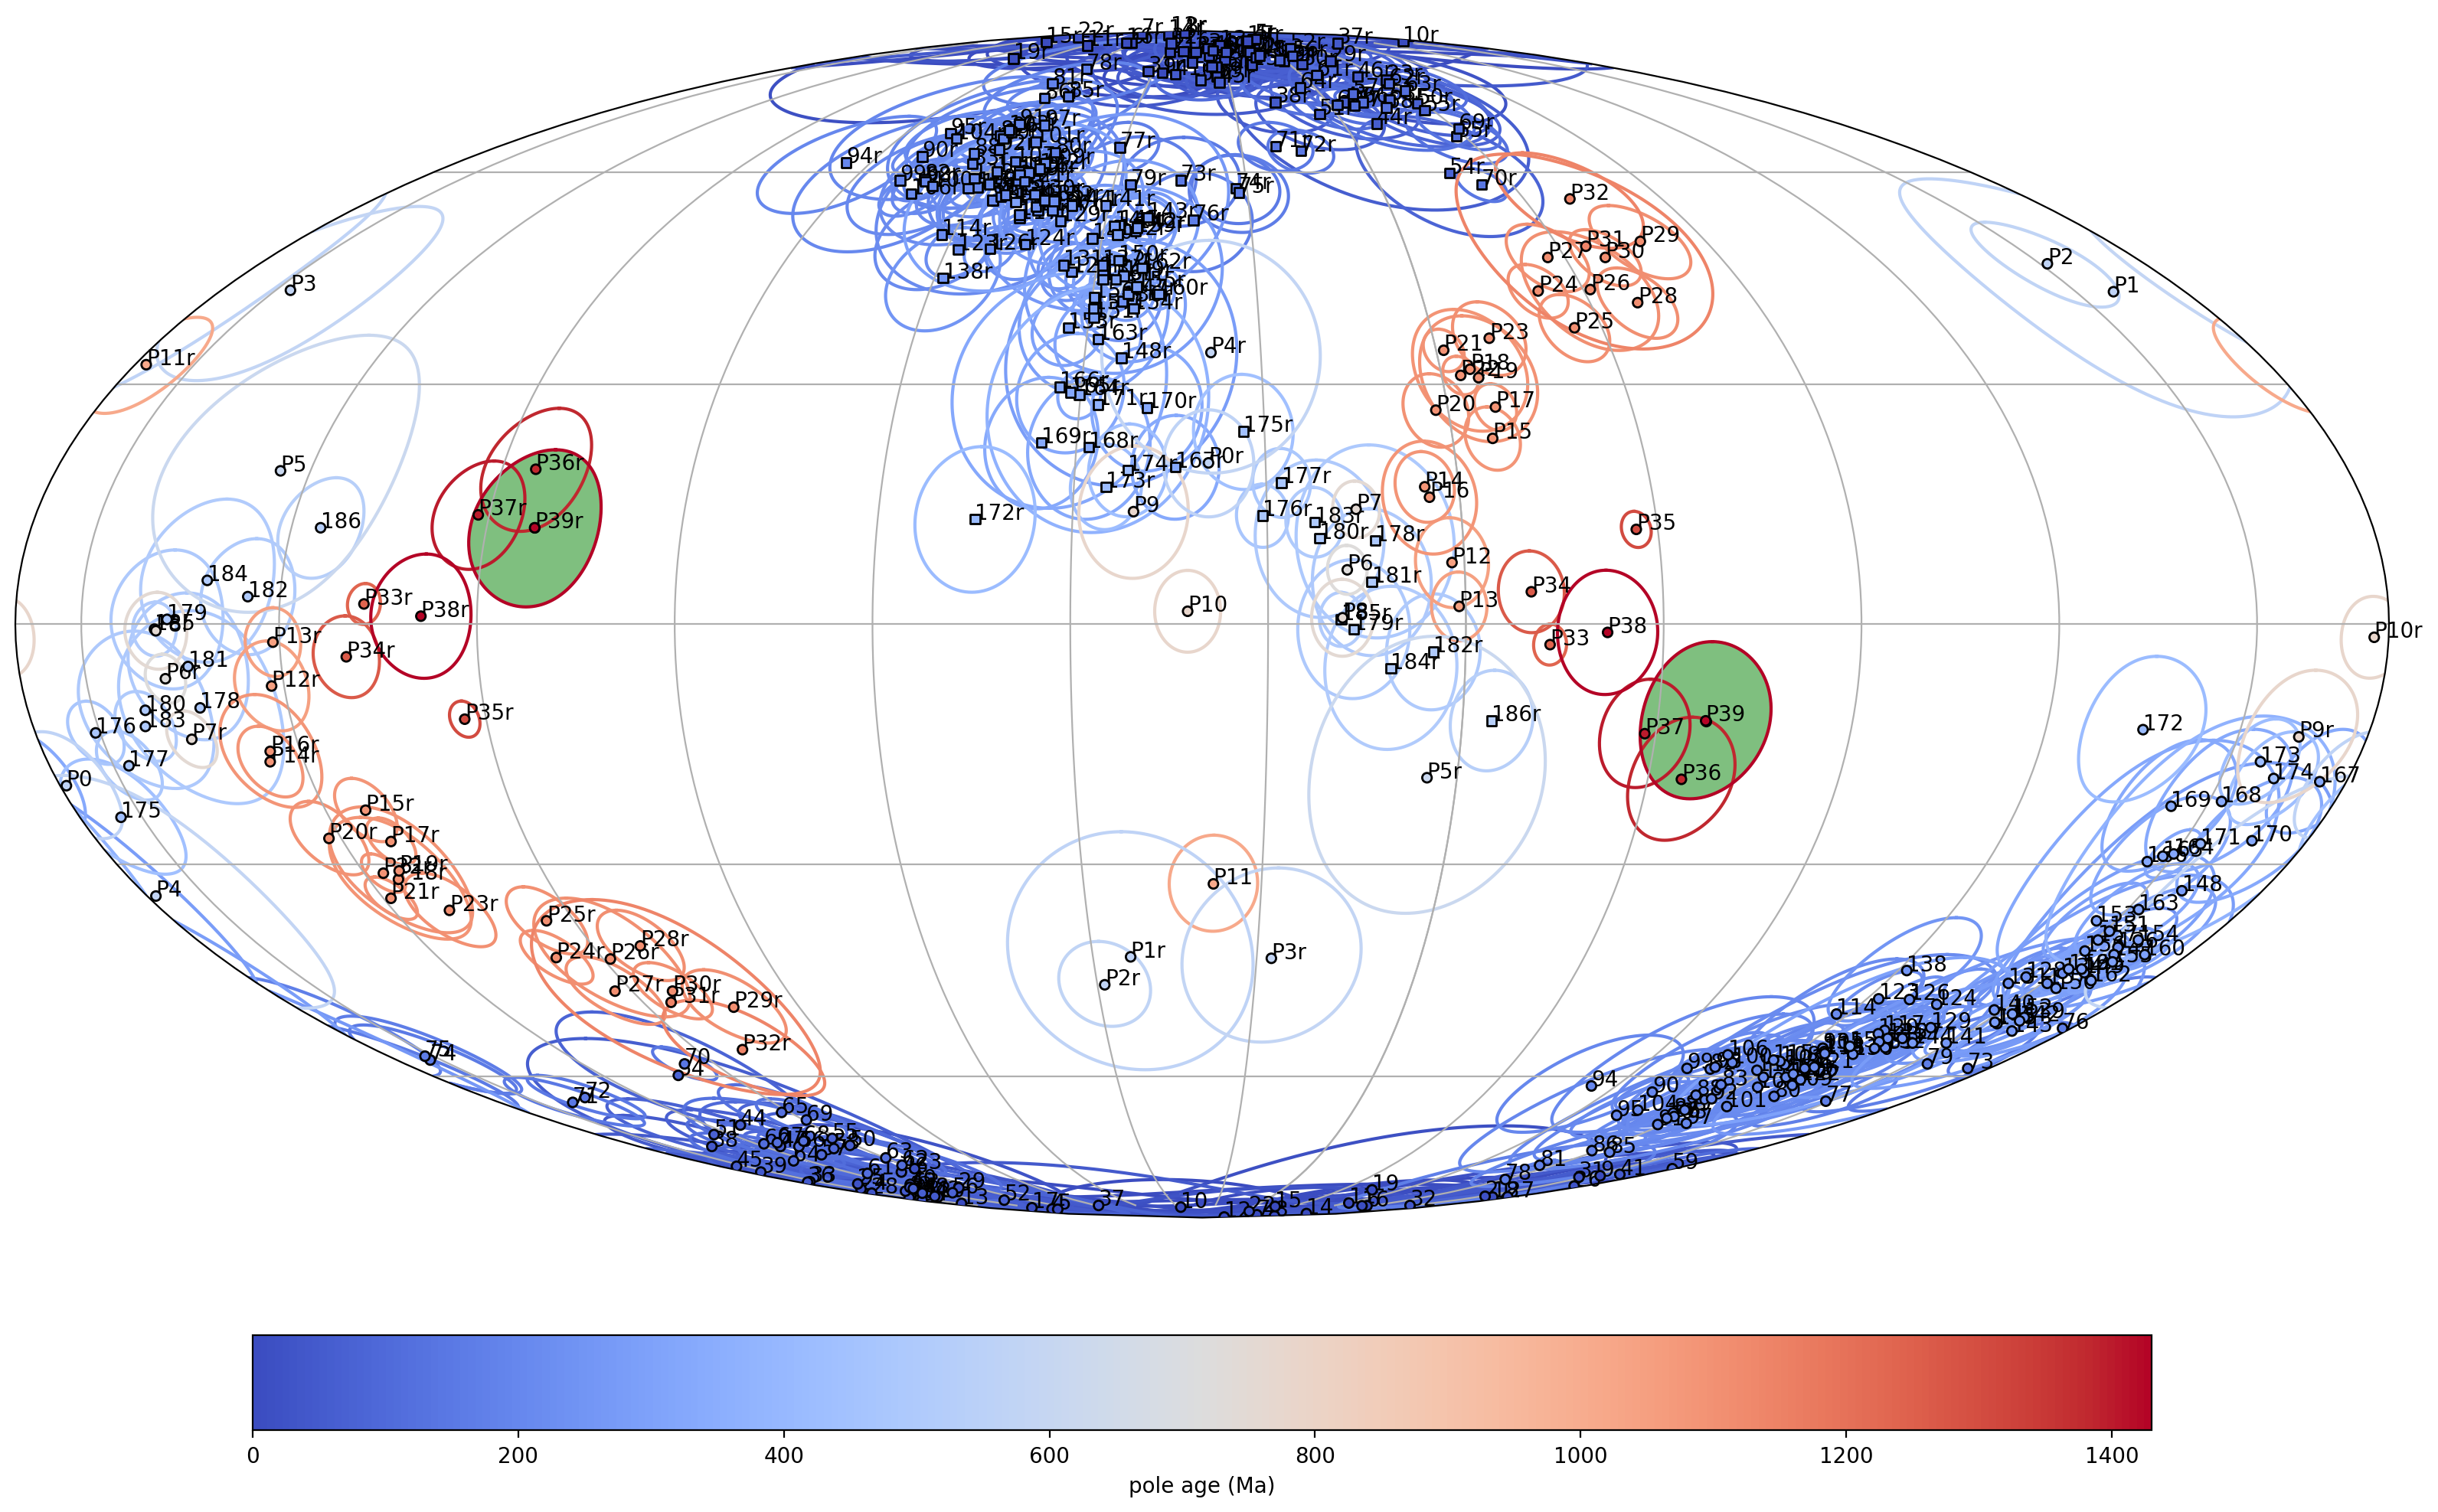

In [65]:
plot_pole_overlap('MEAN Rocky Mountain intrusions',Laurentia_stricto_poles,Torsvik2012_Laurentia)